# Линейная регрессия

Линейная регрессия – один из самых простых и важных алгоритмов машинного обучения. Её идея – описать зависимость целевой
переменной от признаков линейной функцией и подобрать параметры так, чтобы предсказания были максимально близки к
наблюдениям.

Пусть у нас есть набор данных из $N$ объектов: для каждого объекта известны признаки $\mathbf{x}_i$ и целевое значение
$y_i$. Мы хотим найти такую линейную функцию:

$$y = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b = \mathbf{w}^T \mathbf{x} + b$$

где:
- $\mathbf{w} = (w_1, w_2, \ldots, w_n)^T$ — вектор весов (параметров модели)
- $b$ — свободный член (bias)
- $\mathbf{x} = (x_1, x_2, \ldots, x_n)^T$ — вектор признаков объекта

![Бриллианты](../../production/AI_Machine_Learning.Project_3.ID_1577773/misc/images/diamonds.png)

Чтобы быстро перейти от теории к практике, возьмём реальный датасет о бриллиантах. Один из ключевых факторов цены –
каратность. Для начала предположим простую модель с одним признаком:

$$y = w \cdot x + b + \varepsilon$$

где:
- $y$ – цена бриллианта
- $x$ – каратность
- $b$ – базовая цена (свободный член)
- $w$ – «цена» одного карата (коэффициент при признаке)
- $\varepsilon$ – шум (то, что модель не объясняет)

Чтобы по каратности предсказывать цену для новых камней, нужно оценить параметры $w$ и $b$ по историческим данным.

Один из способов – аналитическое решение через метод наименьших квадратов (МНК). В матричной записи это приводит к
«нормальному уравнению»:

$$X^T (y - X\hat{w}) = 0$$
$$X^T X\hat{w} = {X}^T y$$
Если $X^T X$ обратима, то:
$$\hat{w} = (X^T X)^{-1} X^T y$$

## Задание 1. Аналитическое решение

В этом задании тебе требуется построить линейную модель для предсказания стоимости бриллианта на основе его каратности с помощью метода наименьших квадратов (МНК). Ты реализуешь аналитическое решение «вручную», используя матричные операции, а затем проверишь правильность своей реализации, сравнив результаты с библиотекой `sklearn`.

1. **Подготовка данных:**
   - Загрузи датасет `diamonds.csv`.
   - Возьми один признак: каратность (`carat`) и целевую переменную: цену (`price`).
   - Сформируй матрицу признаков `X` размера $N \times 1$ и вектор ответов `y` размера $N$.

2. **Реализация аналитического решения (МНК):**
   - Добавь к `X` столбец единиц, чтобы учитывать свободный член $b$.
   - Вычисли $\hat{w}$ по формуле: $\hat{w} = (X^T X)^{-1} X^T y$.
   - Выведи полученные параметры модели: $b$ (свободный член) и $w$ (коэффициент при каратности).
   - Интерпретируй результаты: что означает полученное значение $w$? Какую цену будет иметь бриллиант с нулевой каратностью (параметр $b$)?

3. **Сравнение с `sklearn`:**
   - Обучи `LinearRegression` из `sklearn.linear_model` на тех же `X` и `y`.
   - Сравни коэффициенты: они должны совпасть или быть очень близкими (например, через `np.allclose`).

4. **Оценка качества и визуализация:**
   - Посчитай MAE (Mean Absolute Error, среднюю абсолютную ошибку) для аналитического решения.
   - Посчитай MAE для решения через `sklearn`.
   - Построй график: точки (реальные данные) и прямая регрессии (предсказания модели).

In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../production/AI_Machine_Learning.Project_3.ID_1577773/datasets/diamonds.csv")

In [3]:
X = df["carat"].values.reshape(-1, 1)
y = df["price"].values.reshape(-1, 1)

print(f"Размер данных: {X.shape[0]} образцов")
print(f"Диапазон carat: {X.min():.2f} - {X.max():.2f} карат")
print(f"Диапазон price: {y.min()} - {y.max()} долларов")

Размер данных: 53940 образцов
Диапазон carat: 0.20 - 5.01 карат
Диапазон price: 326 - 18823 долларов


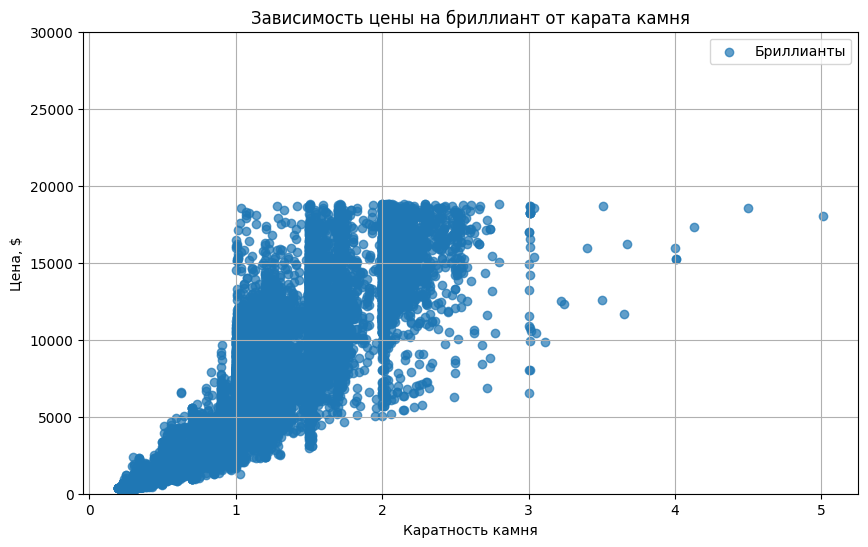

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, label="Бриллианты")
plt.xlabel("Каратность камня")
plt.ylabel("Цена, $")
plt.title("Зависимость цены на бриллиант от карата камня")
plt.ylim(0, 30000)
plt.grid(True)
plt.legend()
plt.show()

In [5]:
X_b = np.c_[np.ones((len(X), 1)), X]
w_analytic = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T.dot(y))

In [6]:
b_v1 = w_analytic[0][0]
w_v1 = w_analytic[1][0]

In [7]:
sklearn_model = LinearRegression()
sklearn_model.fit(X, y)

LinearRegression()

In [8]:
b_v2 = sklearn_model.intercept_[0]
w_v2 = sklearn_model.coef_[0][0]

In [9]:
print(f"\nСравнение коэффициентов:")
print(f"Аналитическое решение: b = {b_v1:.2f}, w = {w_v1:.2f}")
print(f"sklearn: b = {b_v2}, w = {w_v2:.2f}")


Сравнение коэффициентов:
Аналитическое решение: b = -2256.36, w = 7756.43
sklearn: b = -2256.360580045753, w = 7756.43


In [10]:
print(f"Коэффициенты совпадают? - {np.allclose([b_v1, w_v1], [b_v2, w_v2])}")

Коэффициенты совпадают? - True


In [11]:
y_pred = w_analytic[0] + w_analytic[1] * X
mae_analytic = mean_absolute_error(y, y_pred)

y_sklearn = sklearn_model.predict(X)
mae_sklearn = mean_absolute_error(y, y_sklearn)
print(f"\nMAE для аналитического решения: {mae_analytic:.2f}")
print(f"MAE для sklearn: {mae_sklearn:.2f}")


MAE для аналитического решения: 1007.46
MAE для sklearn: 1007.46


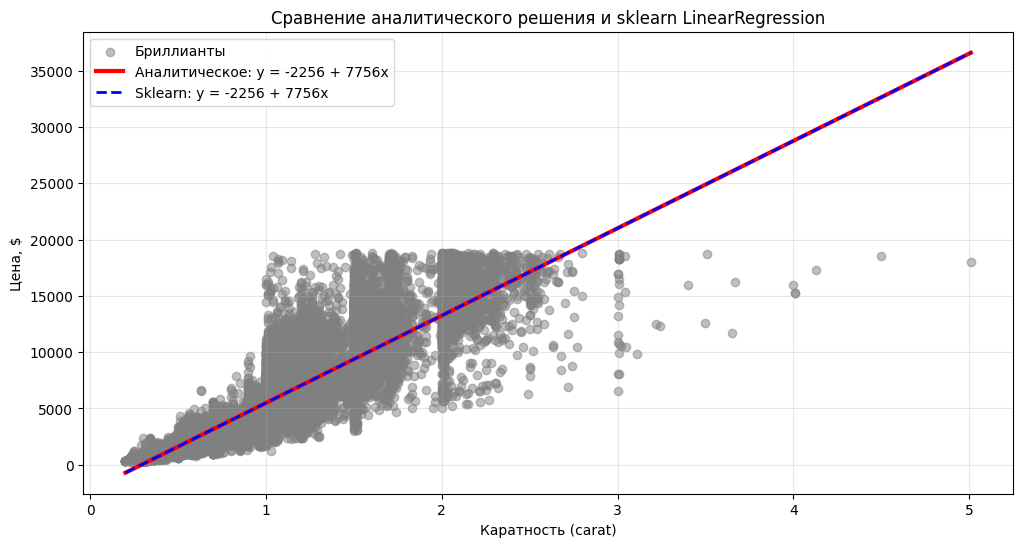

In [12]:
plt.figure(figsize=(12, 6))
plt.scatter(X, y, alpha=0.5, label="Бриллианты", color="gray")

x_range = np.array([[X.min()], [X.max()]])

# Аналитическое решение
y_analytic = w_analytic[0] + w_analytic[1] * x_range
plt.plot(x_range, y_analytic, "r-", linewidth=3, 
         label=f'Аналитическое: y = {w_analytic[0][0]:.0f} + {w_analytic[1][0]:.0f}x')

# Sklearn решение
y_sklearn = sklearn_model.predict(x_range)
plt.plot(x_range, y_sklearn, "b--", linewidth=2, 
         label=f'Sklearn: y = {sklearn_model.intercept_[0]:.0f} + {sklearn_model.coef_[0][0]:.0f}x')

plt.xlabel("Каратность (carat)")
plt.ylabel("Цена, $")
plt.title("Сравнение аналитического решения и sklearn LinearRegression")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Почему аналитическое решение не используется на практике?**

Основные проблемы:
- **Сложность вычислений**: $O(d^3)$, где $d$ — число признаков. Это становится невозможно вычислить для огромных датасетов.
- **Память**: Требуется хранить матрицу $X^TX$, что становится невозможным при большом $d$.
- **Численная нестабильность**: Матрица $X^TX$ может быть плохо обусловленной.

**Решение — градиентный спуск**

Градиентный спуск позволяет эффективно обучать модель даже на больших данных, избегая вычислительных и памяти затрат аналитического подхода.

Основная идея: мы хотим минимизировать функцию потерь — среднеквадратичную ошибку (MSE):

$$
L(w_0, w_1) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

где предсказание модели:

$$
\hat{y}_i = w_0 + w_1 x_{i1} + w_2 x_{i2} + \dots + w_d x_{id}
$$

или в компактной форме:

$$
\hat{y}_i = w_0 + w^\top x_i
$$

Для минимизации функции потерь мы будем использовать её **градиент**.

Градиент — это вектор, составленный из частных производных функции.  
Он показывает направление, в котором функция растёт быстрее всего.  
Поэтому, чтобы двигаться к минимуму, нам нужно идти в **противоположную** сторону — против градиента.

Следовательно, обновлять параметры будем по такому правилу:

$$
w_0 \leftarrow w_0 - \alpha \cdot \frac{\partial L}{\partial w_0}
$$

$$
w_j \leftarrow w_j - \alpha \cdot \frac{\partial L}{\partial w_j}, \quad j = 1, \dots, d
$$

где $\alpha$ — шаг (learning rate).

## Задание 2. Градиент функции потерь

Чтобы реализовать градиентный спуск, нужно знать, в каком направлении изменять параметры модели. Для этого требуется вычислить градиент функции потерь — вектор частных производных по каждому параметру. Градиент показывает направление наибольшего роста функции, поэтому для минимизации мы движемся в противоположном направлении.

В этом задании тебе нужно вычислить градиент функции потерь $L$ — найти частные производные по $w_0$ и $w_1$.  
Запиши:

$$
\frac{\partial L}{\partial w_0} = \dots
$$

$$
\frac{\partial L}{\partial w_1} = \dots
$$

$$\frac{\partial L}{\partial w_0} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) = -\frac{2}{n} \sum_{i=1}^{n} (y_i - w_0 - w_1 x_i)$$
$$\frac{\partial L}{\partial w_1} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) x_i = -\frac{2}{n} \sum_{i=1}^{n} (y_i - w_0 - w_1 x_i) x_i$$

## Задание 3. Обновление параметров

Теперь, когда ты знаешь, как вычисляется градиент функции потерь, можно перейти к практической реализации. В этом задании ты создашь класс `Gradient`, который инкапсулирует логику работы с градиентами и обновления параметров модели. Этот класс станет основой для реализации полного алгоритма градиентного спуска в следующем задании.

Класс будет содержать методы для предсказания, вычисления ошибки и обновления параметров согласно формулам градиентного спуска, которые ты вывел в предыдущем задании.

1. **Реализация класса `Gradient`:**
   - Напиши класс `Gradient()`, который при инициализации получает два вектора: `X` (признаки) и `Y` (целевая переменная).
   - Реализуй методы класса согласно их docstrings и аннотациям типов (type hints).
   - Обрати внимание на сигнатуры методов и их возвращаемые значения: `predict` возвращает массив предсказаний, `mse` возвращает число, `update` возвращает кортеж из двух элементов.

2. **Проверка работы методов:**
   - Инициализируй класс с данными `X`, `Y` из задания 1 (признак `carat` и целевая переменная `price`).
   - Задай начальные параметры (например, `w=0`, `b=0`).
   - Вызови `predict` и `mse` для проверки корректности работы методов.
   - Вызови `update` несколько раз (2-3 итераций) и покажи, как изменяются ошибка (MSE) и параметры `w`, `b` после каждого обновления.

In [13]:
class Gradient:
    def __init__(self, X: np.array, Y: np.array) -> None:
        self.X = np.asarray(X)
        self.Y = np.asarray(Y).flatten()
        self.N = len(self.Y)
        self.n_features = self.X.shape[1] if self.X.ndim > 1 else 1

    def predict(self, w: np.array, b: float):
        return self.X @ w + b

    def mse(self, prediction: np.array):
        return np.mean((self.Y - prediction) ** 2)

    def update(self, w: np.array, b: float, a: float = 0.01) -> (np.array, float):
        prediction = self.predict(w, b)
        errors = self.Y - prediction

        grad_w = -2 / self.N * (self.X.T @ errors)
        grad_b = -2 / self.N * np.sum(errors)

        w_new = w - a * grad_w
        b_new = b - a * grad_b

        return w_new, b_new

In [14]:
gradient = Gradient(X, y)

In [15]:
b_init = 0.0
w_init = np.zeros(X.shape[1])

In [16]:
y_prediction = gradient.predict(w_init, b_init)
gradient.mse(y_prediction)

31382248.015257694

In [17]:
w_new, b_new = gradient.update(w_init, b_init)
y_prediction = gradient.predict(w_new, b_new)
gradient.mse(y_prediction)

29837304.246570382

In [18]:
w_new, b_new = gradient.update(w_new, b_new)
y_prediction = gradient.predict(w_new, b_new)
gradient.mse(y_prediction)

28395300.853477735

## Задание 4. Градиентный спуск

Теперь, когда у тебя есть класс `Gradient` с методами для обновления параметров, можно реализовать полный алгоритм градиентного спуска. В этом задании ты создашь класс `GradientDescent`, который наследуется от `Gradient` и автоматизирует процесс обучения модели: итеративно обновляет параметры, отслеживает историю обучения и останавливается по заданным критериям.

Важной особенностью реализации будет адаптивный learning rate: в процессе обучения learning rate будет уменьшаться, что позволяет сначала быстро приблизиться к минимуму, а затем точно настроить параметры модели.

1. **Реализация класса `GradientDescent`:**
   - Создай класс `GradientDescent(Gradient)`, который наследует все методы из `Gradient`.
   - Реализуй метод `optimize` согласно его docstrings и аннотациям типов (type hints).
   - Метод должен итеративно обновлять `w` и `b` с помощью метода `update`.
   - **Важно:** learning rate `a` должен уменьшаться в ходе обучения по формуле: $a_t = a_0 \cdot \frac{1}{1 + \text{decay} \cdot t}$, где $a_0$ — начальный learning rate, $t$ — номер итерации, $\text{decay} = 0.01$ — коэффициент затухания.
   - Критерии остановки:
     - Превышено количество итераций `num_iterations`
     - Изменение MSE между итерациями меньше `stopping_threshold`
   - Метод должен вернуть словарь с ключами: `'w'`, `'b'`, `'mse'`, `'history'` (список значений MSE на каждой итерации), `'iterations'` (количество выполненных итераций)

2. **Визуализация и анализ:**
   - Обучи модель на данных `X`, `Y` с разными значениями learning rate: `[0.0000001, 0.001, 1]`.
   - Для каждого learning rate построй график зависимости MSE от номера итерации.
   - На отдельном графике визуализируй финальные линии регрессии для разных learning rate.

3. **Сравнение с аналитическим решением:**
   - Сравни полученные градиентным спуском значения с аналитическим решением из задания 1.
   - Визуализируй оба решения на одном графике.

In [19]:
class GradientDescent(Gradient):
    """
    Класс для реализации полного алгоритма градиентного спуска.
    
    Наследуется от класса Gradient и добавляет метод optimize для автоматизации
    процесса обучения модели с адаптивным learning rate.
    """
    def optimize(self, num_iterations: int, stopping_threshold: float = 0.001, 
                 a: float = 0.000001, w_init: float = 0, b_init: float = 0) -> dict:
        """
        Оптимизирует параметры модели с помощью градиентного спуска.
        
        Parameters:
        -----------
        num_iterations : int
            Максимальное количество итераций обучения
        stopping_threshold : float, default=0.001
            Порог остановки: обучение прекращается, если изменение MSE между
            итерациями меньше этого значения
        a : float, default=0.000001
            Начальный learning rate (будет уменьшаться в ходе обучения)
        w_init : float, default=0
            Начальное значение параметра w
        b_init : float, default=0
            Начальное значение параметра b
            
        Returns:
        --------
        result : dict
            Словарь с ключами:
            - 'w': np.ndarray - финальные параметры w
            - 'b': float - финальный параметр b
            - 'mse': float - финальное значение MSE
            - 'history': list - список значений MSE на каждой итерации
            - 'iterations': int - количество выполненных итераций
            
        Note:
        -----
        Learning rate уменьшается по формуле: a_t = a_0 / (1 + decay * t),
        где decay = 0.01, t - номер итерации.
                """
        if isinstance(w_init, (int, float)):
            w = np.full(self.n_features, w_init, dtype=float)
        else:
            w = np.asarray(w_init).flatten()[:self.n_features]
        b = float(b_init)
        
        history = []
        prev_mse = float('inf')
        a_initial = a
        decay = 0.01
        
        for i in range(num_iterations):
            a_current = a_initial / (1 + decay * i)
            
            Y_pred = self.predict(w, b)
            mse = self.mse(Y_pred)
            history.append(mse)
            
            if i > 0 and abs(prev_mse - mse) < stopping_threshold:
                break
                
            w, b = self.update(w, b, a_current)
            prev_mse = mse
        
        return {
            'w': w,
            'b': b,
            'mse': self.mse(self.predict(w, b)),
            'history': history,
            'iterations': len(history)
        }

In [20]:
learning_rates = [0.0001, 0.1, 1]

results = {}
for lr in learning_rates:
    gd = GradientDescent(X, y)
    result = gd.optimize(num_iterations=1000, stopping_threshold=0.01, a=lr, w_init=0, b_init=0)
    results[lr] = result

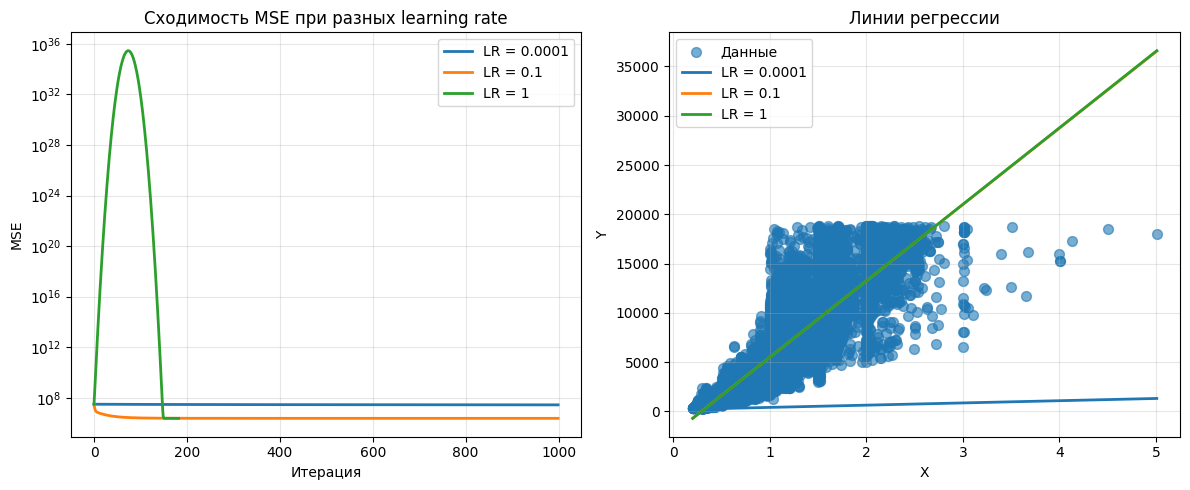

In [21]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for lr in learning_rates:
    history = results[lr]['history']
    plt.plot(history, label=f'LR = {lr}', linewidth=2)

plt.xlabel('Итерация')
plt.ylabel('MSE')
plt.title('Сходимость MSE при разных learning rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.6, label='Данные', s=50)

x_line = np.linspace(X.min(), X.max(), 100)
for lr in learning_rates:
    w = results[lr]['w']
    b = results[lr]['b']
    w_scalar = w[0] if isinstance(w, np.ndarray) and w.ndim > 0 else w
    y_line = w_scalar * x_line + b
    plt.plot(x_line, y_line, label=f'LR = {lr}', linewidth=2)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Линии регрессии')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

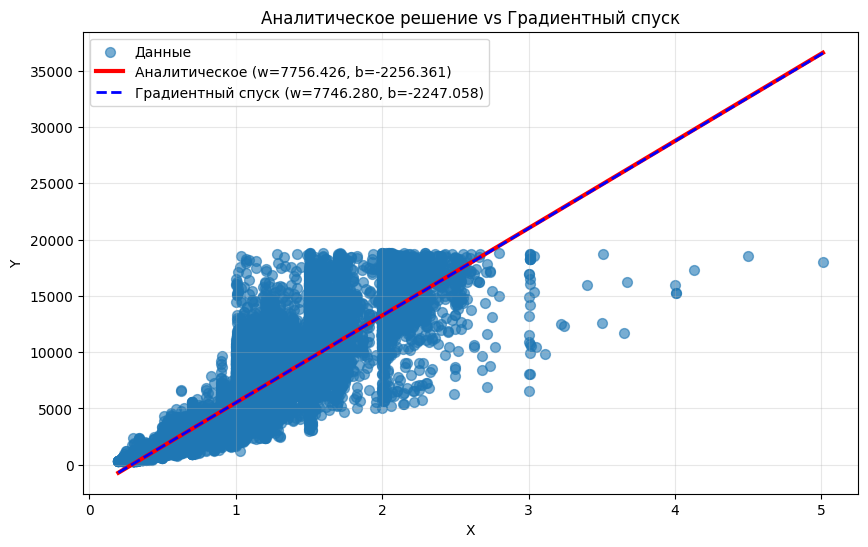

In [22]:
x_mean = np.mean(X)
y_mean = np.mean(y)
w_analytical = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean)**2)
b_analytical = y_mean - w_analytical * x_mean

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label='Данные', s=50)

x_line = np.linspace(X.min(), X.max(), 100)

# Аналитическое
y_analytical = w_analytical * x_line + b_analytical
plt.plot(x_line, y_analytical, 'r-', linewidth=3, 
         label=f'Аналитическое (w={w_analytical:.3f}, b={b_analytical:.3f})')

w_gd = results[0.1]['w']
b_gd = results[0.1]['b']
w_gd_scalar = w_gd[0] if isinstance(w_gd, np.ndarray) and w_gd.ndim > 0 else w_gd
y_gd = w_gd_scalar * x_line + b_gd
plt.plot(x_line, y_gd, 'b--', linewidth=2, 
         label=f'Градиентный спуск (w={w_gd_scalar:.3f}, b={b_gd:.3f})')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Аналитическое решение vs Градиентный спуск')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
results[0.1]["mse"]

2397979.6354109426

## Задание 5. Используем все данные

Попробуем улучшить результат предсказания цены бриллианта, используя все доступные признаки датасета (каратность,
огранка, цвет, чистота, глубина, таблица, размеры x, y, z).

1. Преобразуй все признаки: OneHotEncoder для категориальных, при необходимости StandardScaler для числовых.
2. Раздели данные на обучающую и тестовую выборку (train_test_split, например 80% / 20%, random_state=21).
3. Обучи SGDRegressor из sklearn.linear_model на обучающей выборке.
4. Посчитай метрики качества на тестовой выборке (MAE и MSE) и сравни с моделью только по каратности.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [25]:
df_full = pd.read_csv("../../production/AI_Machine_Learning.Project_3.ID_1577773/datasets/diamonds.csv")
y_full = df_full["price"]
X_full = df_full.drop(columns=["price"])

In [26]:
X_encoded = pd.get_dummies(X_full, columns=["cut", "color", "clarity"])

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_full, test_size=0.2, random_state=21
)

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
model_all = SGDRegressor()
model_all.fit(X_train_scaled, y_train)

SGDRegressor()

In [30]:
y_pred_test = model_all.predict(X_test_scaled)
mae_all = mean_absolute_error(y_test, y_pred_test)
mse_all = mean_squared_error(y_test, y_pred_test)

In [31]:
print("Метрики модели на всех признаках (тестовая выборка):")
print(f"  MAE:  {mae_all:.2f}")
print(f"  MSE:  {mse_all:.2f}")

Метрики модели на всех признаках (тестовая выборка):
  MAE:  739.63
  MSE:  1249089.80


In [32]:
X_train_carat = X_train[["carat"]].values
X_test_carat = X_test[["carat"]].values
model_carat = SGDRegressor()
model_carat.fit(X_train_carat, y_train)
y_pred_carat = model_carat.predict(X_test_carat)
mae_carat = mean_absolute_error(y_test, y_pred_carat)
mse_carat = mean_squared_error(y_test, y_pred_carat)

In [33]:
print("\nМетрики модели только по каратности (тестовая выборка):")
print(f"  MAE:  {mae_carat:.2f}")
print(f"  MSE:  {mse_carat:.2f}")
print(f"\nИспользование всех признаков снизило MAE на {mae_carat - mae_all:.2f}")


Метрики модели только по каратности (тестовая выборка):
  MAE:  1001.83
  MSE:  2347056.51

Использование всех признаков снизило MAE на 262.20


## Задание 6. Ridge и Lasso регрессии

Регуляризация ограничивает сложность модели штрафом за большие веса. Ridge (L2) уменьшает все веса, Lasso (L1) обнуляет часть весов и отбирает признаки. Сравним Ridge и Lasso с моделью без регуляризации на тех же данных (X_train_scaled, X_test_scaled, y_train, y_test из задания 5).

In [34]:
from sklearn.linear_model import Ridge, Lasso

In [40]:
model_ridge = Ridge(alpha=0.01)
model_ridge.fit(X_train_scaled, y_train)
y_pred_ridge = model_ridge.predict(X_test_scaled)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

model_lasso = Lasso(alpha=0.01)
model_lasso.fit(X_train_scaled, y_train)
y_pred_lasso = model_lasso.predict(X_test_scaled)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.717e+08, tolerance: 6.910e+07
  model = cd_fast.enet_coordinate_descent(


In [41]:
print("Сравнение моделей на тестовой выборке:")
print(f"  Без регуляризации (SGDRegressor): MAE = {mae_all:.2f}, MSE = {mse_all:.2f}")
print(f"  Ridge (alpha=0.01):               MAE = {mae_ridge:.2f}, MSE = {mse_ridge:.2f}")
print(f"  Lasso (alpha=0.01):              MAE = {mae_lasso:.2f}, MSE = {mse_lasso:.2f}")
print(f"\nИзменение MAE относительно модели без регуляризации:")
print(f"  Ridge: {mae_ridge - mae_all:+.2f}")
print(f"  Lasso: {mae_lasso - mae_all:+.2f}")

Сравнение моделей на тестовой выборке:
  Без регуляризации (SGDRegressor): MAE = 739.63, MSE = 1249089.80
  Ridge (alpha=1.0):               MAE = 730.86, MSE = 1220559.04
  Lasso (alpha=0.001):             MAE = 730.87, MSE = 1220557.43

Изменение MAE относительно модели без регуляризации:
  Ridge: -8.77
  Lasso: -8.77
